### Exploring the correlation of antibody´s **light subclass** with the *antigen species* that it targets 

In [2]:
from Bio import SeqIO
import pandas as pd

#loading the columns of the sars hum dataframe
df_sars_hum = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t", usecols=["pdb", "light_subclass", "antigen_species"])
df_sars_hum['pdb'] = df_sars_hum['pdb'].str.lower().str.strip()
print(df_sars_hum.head())

    pdb            antigen_species light_subclass
0  8wu1  bos taurus | homo sapiens          IGKV1
1  3lqa       hiv-1 | homo sapiens          IGLV1
2  4kxz               homo sapiens          IGKV3
3  6vmk               homo sapiens          IGKV1
4  6vmk               homo sapiens          IGKV1


In [3]:
import numpy as np
import pandas as pd
#loading distance matrix 
dist_matrix = pd.read_csv("../../blasting/mmseqs/distance_matrix.csv", index_col=0)

#consistent formating
dist_matrix.index = dist_matrix.index.str.strip()
dist_matrix.columns = dist_matrix.columns.str.strip()
pdb_id = df_sars_hum['pdb'].unique()

#creating a dataframe with merged distance matrix and gene families with the pdb-IDs 
def extract_pdb(full_id):
    return full_id.split('_')[0].lower()  #lowercase to match pdb IDs like '8wu1'

#rows and columns are applied to the matrix
dist_matrix.index = dist_matrix.index.map(extract_pdb)
dist_matrix.columns = dist_matrix.columns.map(extract_pdb)

df_sars_hum = df_sars_hum[df_sars_hum['pdb'].isin(dist_matrix.index)]
print(dist_matrix.shape)

#loadint the matrix into a .csv for further use
dist_matrix.to_csv("distance_matrix_light_subclass.csv")
print(dist_matrix.head())


(1013, 1013)
      1adq   1h0d   1i9r   1iqd   1jps   1uj3   1w72   2b4c   2fjh   2j6e  \
1adq   0.0  1.000  1.000  1.000  1.000  1.000  0.044  1.000  1.000  0.226   
1h0d   1.0  0.000  0.349  1.000  1.000  1.000  1.000  0.413  0.395  1.000   
1i9r   1.0  0.349  0.000  1.000  0.179  0.184  1.000  1.000  0.156  1.000   
1iqd   1.0  1.000  1.000  0.000  0.185  1.000  1.000  0.072  0.162  1.000   
1jps   1.0  1.000  0.179  0.185  0.000  0.043  1.000  0.196  0.080  1.000   

      ...   9dh2   9dq3   9e6k   9gox   9gwt   9j66   9l6c   9l6c   9l6c  \
1adq  ...  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000   
1h0d  ...  0.440  0.404  0.390  0.400  0.335  0.418  1.000  1.000  1.000   
1i9r  ...  0.189  1.000  0.138  1.000  0.129  0.175  1.000  1.000  1.000   
1iqd  ...  1.000  0.072  0.072  0.100  1.000  0.190  0.102  1.000  0.075   
1jps  ...  0.108  0.163  0.163  0.164  0.193  0.099  1.000  0.176  1.000   

       9mi6  
1adq  0.215  
1h0d  1.000  
1i9r  1.000  
1iqd  1.000

/home/barth/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/barth/miniforge3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/barth/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


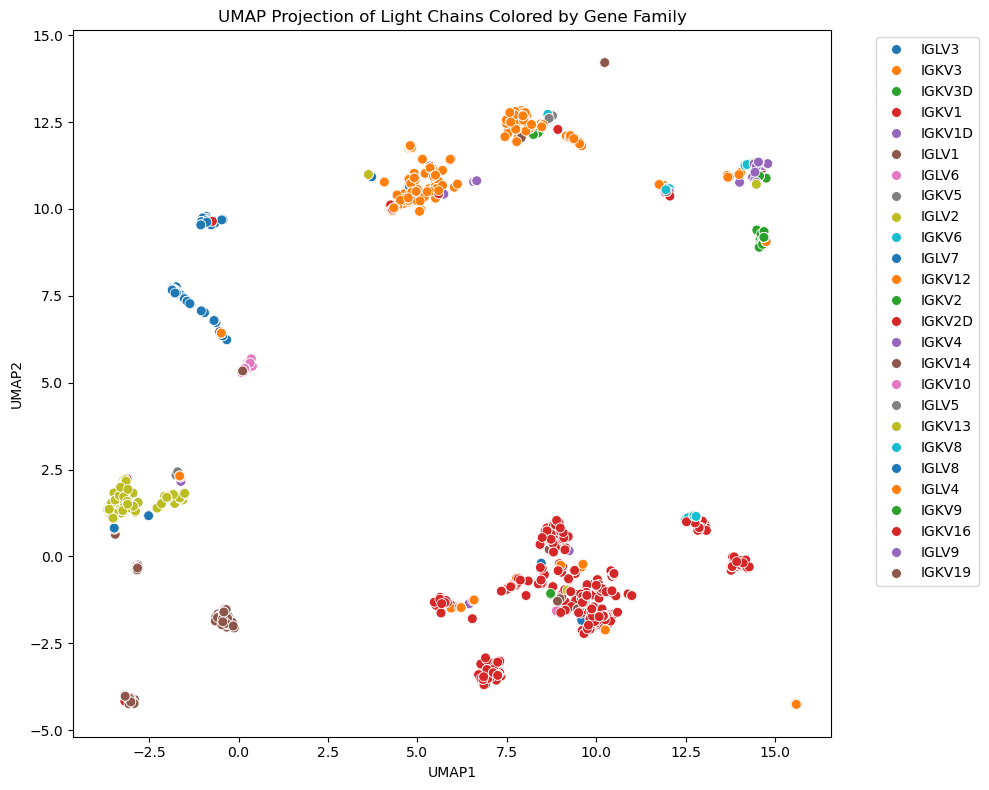

In [4]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

#umap projection
reducer = umap.UMAP(metric='precomputed', random_state=42)
embedding = reducer.fit_transform(dist_matrix)

df_umap = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
df_umap["pdb"] = dist_matrix.index
df_umap = df_umap.merge(df_sars_hum, on="pdb", how="left")

#plotting the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_umap, x="UMAP1", y="UMAP2", hue="light_subclass", palette="tab10", s=50)
plt.title("UMAP Projection of Light Chains Colored by Gene Family")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
import os
import subprocess
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import AlignInfo
from Bio import AlignIO
from collections import defaultdict

#importing multiple sequence alignment fasta file 
fasta_file = "../../blasting/mmseqs/lchain_sequences_deduplicated.fasta"
seq_dict = {
    rec.id.lower().split('_')[0].strip(): rec
    for rec in SeqIO.parse(fasta_file, "fasta")
}

dist_list = [x.lower().strip() for x in dist_matrix.index.tolist()]
df_sars_hum['pdb'] = df_sars_hum['pdb'].str.lower().str.strip()
df_sars_hum = df_sars_hum[df_sars_hum['pdb'].isin(dist_list)]

#ensuring the consistent formating of pdbs and of the table
print(df_sars_hum.head())
print(dist_list)

    pdb            antigen_species light_subclass
0  8wu1  bos taurus | homo sapiens          IGKV1
1  3lqa       hiv-1 | homo sapiens          IGLV1
2  4kxz               homo sapiens          IGKV3
3  6vmk               homo sapiens          IGKV1
4  6vmk               homo sapiens          IGKV1
['1adq', '1h0d', '1i9r', '1iqd', '1jps', '1uj3', '1w72', '2b4c', '2fjh', '2j6e', '2qql', '2qqn', '2qr0', '2uzi', '2vh5', '2vxs', '2wub', '2xqb', '2xtj', '2xwt', '3bn9', '3d85', '3dvg', '3dvn', '3eob', '3g04', '3g6d', '3g6j', '3gjf', '3grw', '3hae', '3hi6', '3hmx', '3jwo', '3kr3', '3l5x', '3lqa', '3mxw', '3n85', '3nfp', '3nh7', '3nps', '3p0y', '3q1s', '3r1g', '3skj', '3so3', '3sob', '3sqo', '3t2n', '3thm', '3tje', '3u30', '3ulu', '3ulu', '3ulu', '3wd5', '3wlw', '3wsq', '3x3f', '4cni', '4d9r', '4dke', '4dkf', '4dn4', '4dtg', '4edw', '4ers', '4g3y', '4g6j', '4g6m', '4h8w', '4hcr', '4hj0', '4hwb', '4i2x', '4i77', '4j4p', '4k8r', '4k8r', '4kxz', '4lmq', '4mxw', '4n90', '4od2', '4ogx', '4oqt', '4p

In [6]:
#filtering df_sars_hum so that it only contains pdbs that are as well in seq_dict (the headers of fasta file)
grouped_sequences = defaultdict(list)

for _, row in df_sars_hum.iterrows():
    pdb_id = row['pdb']
    subclass = row['light_subclass']
    if pdb_id in seq_dict:
        grouped_sequences[subclass].append(seq_dict[pdb_id])

#clustal alignment 
written_files = []
#filtering the files, so that clustal alignment works (deleting ids, name, description)
for subclass, recs in grouped_sequences.items():
    if len(recs) > 1:
        for rec in recs:
            rec.id = rec.id.split()[0]
            rec.id = rec.id.replace(">", "").strip()
            rec.name = rec.id
            rec.description = ""

        input_path = f"clustal_alignments/{subclass}_in.fasta"
        SeqIO.write(recs, input_path, "fasta")
        written_files.append(input_path)


print("PDBs from df_sars_hum:", df_sars_hum['pdb'].unique()[:5])
print("Keys from seq_dict:", list(seq_dict.keys())[:5])

PDBs from df_sars_hum: ['8wu1' '3lqa' '4kxz' '6vmk' '8ivx']
Keys from seq_dict: ['8ivx', '7zoz', '8ivw', '6vmk', '6mhr']


In [7]:
for subclass in grouped_sequences:
    in_path = f"clustal_alignments/{subclass}_in.fasta"
    out_path = f"clustal_alignments/{subclass}_aligned.fasta"
    
    #making sure the file exists before aligning + running clustal omega
    if os.path.exists(in_path):
        subprocess.run([
            "clustalo", "-i", in_path,
            "-o", out_path,
            "--force", "--outfmt", "fasta"
        ], check=True)

In [8]:

import json

#storing consensus sequencing by the light subclass in the dictionary
consensus_dict = {}

for subclass in grouped_sequences:
    aligned_path = f"clustal_alignments/{subclass}_aligned.fasta"
    if os.path.exists(aligned_path):
        alignment = AlignIO.read(aligned_path, "fasta")
        summary = AlignInfo.SummaryInfo(alignment)

        #70% of the sequences must be the same in this position, otherwise it is filed with '_'
        consensus = summary.dumb_consensus(threshold=0.7, ambiguous='_') 
        consensus_dict[subclass] = str(consensus)

#printing the consesus dictionary
for subclass, consensus in consensus_dict.items():
    print(f">{subclass}\n{consensus}")

with open("consensus_dict.json", "w") as f:
    json.dump(consensus_dict, f)

/home/barth/miniforge3/lib/python3.12/site-packages/Bio/Align/AlignInfo.py:62: BiopythonDeprecationWarning: The `dumb_consensus` method is deprecated and will be removed in a future release of Biopython. As an alternative, you can convert the multiple sequence alignment object to a new-style Alignment object by via its `.alignment` property, and then create a Motif object. You can then use the `.consensus` or `.degenerate_consensus` property of the Motif object to get a consensus sequence. For more control over how the consensus sequence is calculated, you can call the `calculate_consensus` method on the `.counts` property of the Motif object. This is an example for a multiple sequence alignment `msa` of DNA nucleotides:
>>> from Bio.Seq import Seq
>>> from Bio.SeqRecord import SeqRecord
>>> from Bio.Align import MultipleSeqAlignment
>>> from Bio.Align.AlignInfo import SummaryInfo
>>> msa = MultipleSeqAlignment([SeqRecord(Seq('ACGT')),
...                             SeqRecord(Seq('ATG

>IGKV1
MD_K___IHNHHK___________________DIQMTQSPSSLSASVGDRVTITCRASQ___Y_______L_WYQQKPGKAPKLLIY_AST_L_SGVPSRFSSRATLTGSGSGTDFTLTISSLQPEDFATYYCQQ__________TFG_GTKVEIKR_T_VAAPSVFIFS__PPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS__________QLIMVTNKAIASQ
>IGLV1
MGILPSPGM_______L_L_____G__S_QSVLTQPPS_S__PGQRVTISC_GS_SNLY_NIG____V_WYQQQLPG_APKLLIY____RPSGVPDRFSGSKSGSSTSASLAI_GLQ_EDEADYYC___D_SL_____VFGGGTK_TVL_TKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGSVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSSSTVEKTVAPTECSAAENLYFQGS
>IGKV3
PNITNLCP____________L_________NCVAEIV_TQSP_TLSLSPGERATLSCRASQSV___DLCFTNVYA_______LAWYQQKPGQAPRLLIY_AS_RATGIP_RFSGSGSGTDFTLTIS_LEPEDFAVYYCQQ____PS____TFG_GTKVQ_EIKRT___PTVSIFPPSSEQLTSGGASVVCFTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC____Q______TNGVGY_______LS_A_________C__T__GL____________H
>IGKV6
DIV_TQ___F_S_S____V_ITC_ASQ____YGIS___WYQQKP_QS

In [9]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

#converting consensus sequences into a fasta file and saving it
records = [SeqRecord(Seq(seq), id=subclass, description="") for subclass, seq in consensus_dict.items()]
SeqIO.write(records, "consensus_by_light_subclass.fasta", "fasta")


26

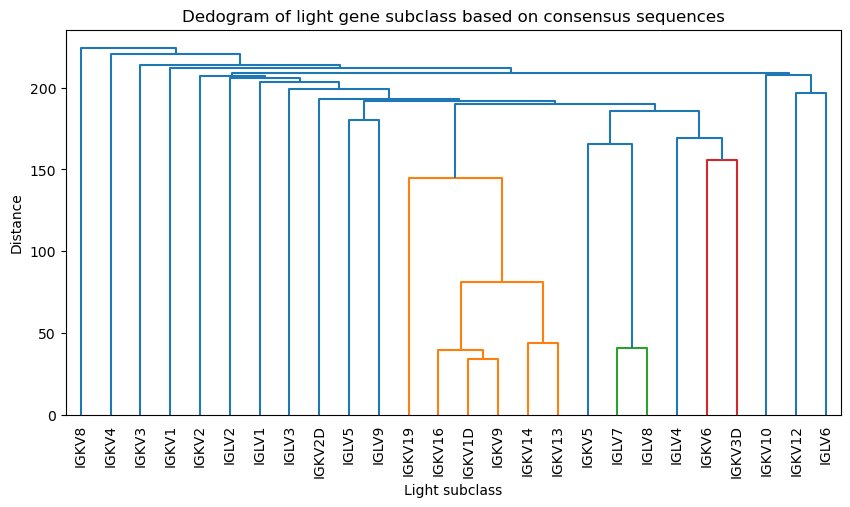

In [10]:
#visualisation of the consensus sequences
import numpy as np
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

#defining function to calulate hamming distance (= how many positions differ in one string of the same lenght)
def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))

#extracting sequences and labels(light subclasses) from consensus dictionary
sequences = list(consensus_dict.values())
labels = list(consensus_dict.keys())

#distance matrix using hamming distance os the consensus sequences
dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])

#applying the linkage method to the matrix 
linkage_matrix = linkage(squareform(dist_matrix), method='average')

#plotting dendogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
plt.title("Dedogram of light gene subclass based on consensus sequences")
plt.ylabel("Distance", fontsize=10)
plt.xlabel("Light subclass", fontsize=10)
plt.show()


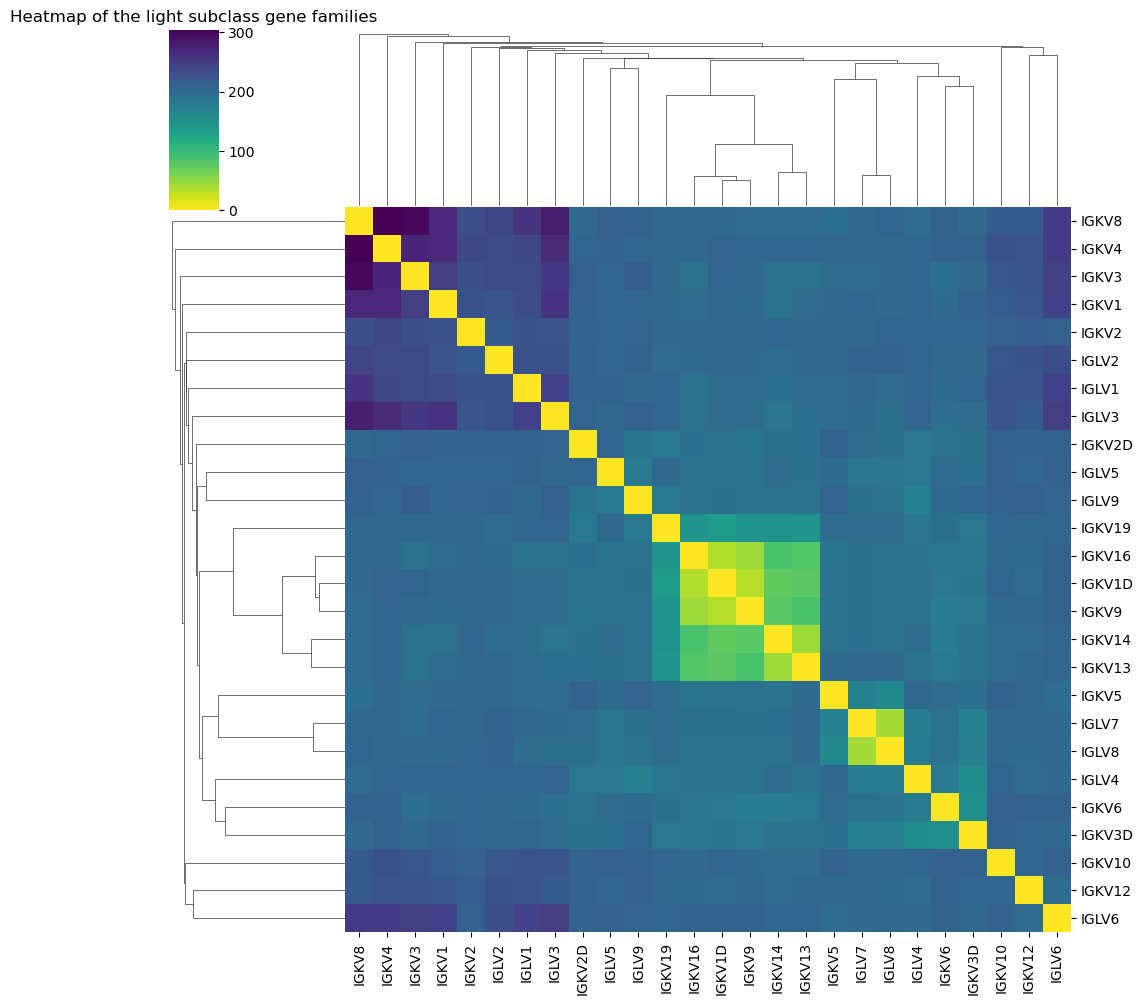

In [11]:
#plotting heatmap
sns.clustermap(dist_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix,
               row_cluster=True, col_cluster=True,
               xticklabels=labels, yticklabels=labels,
               cmap="viridis_r")
plt.title("Heatmap of the light subclass gene families")
plt.show()

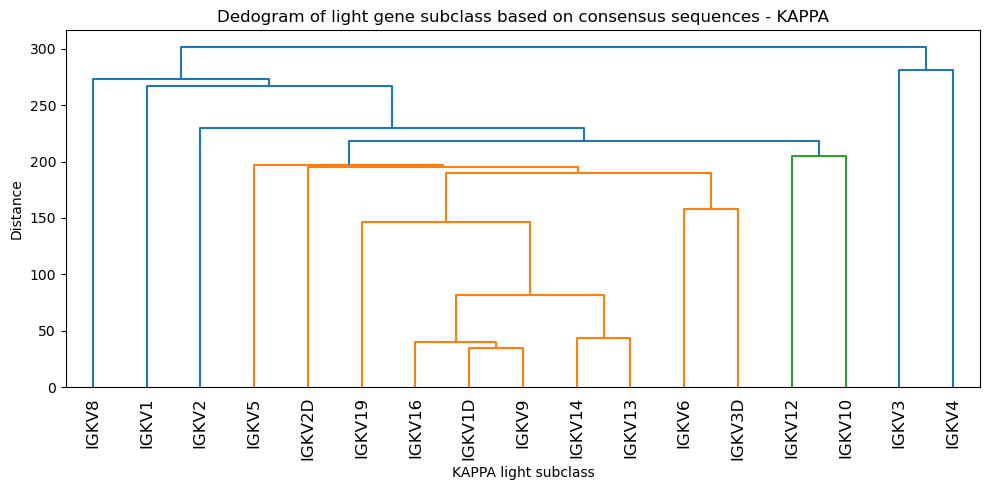

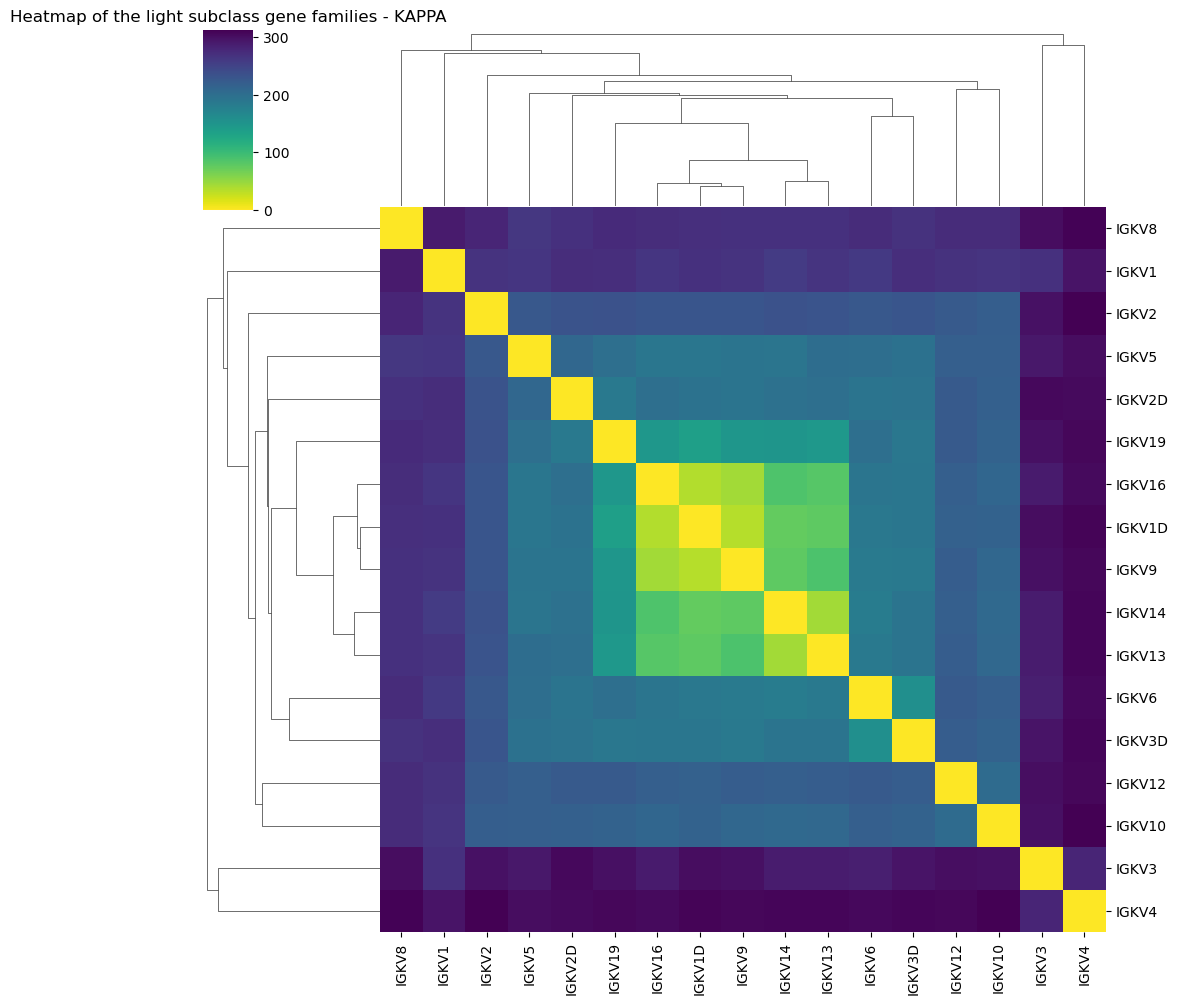

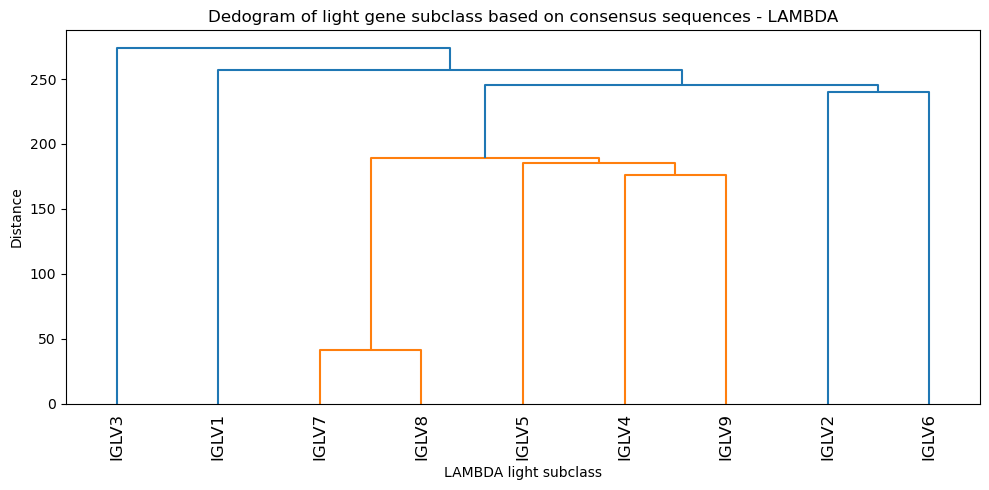

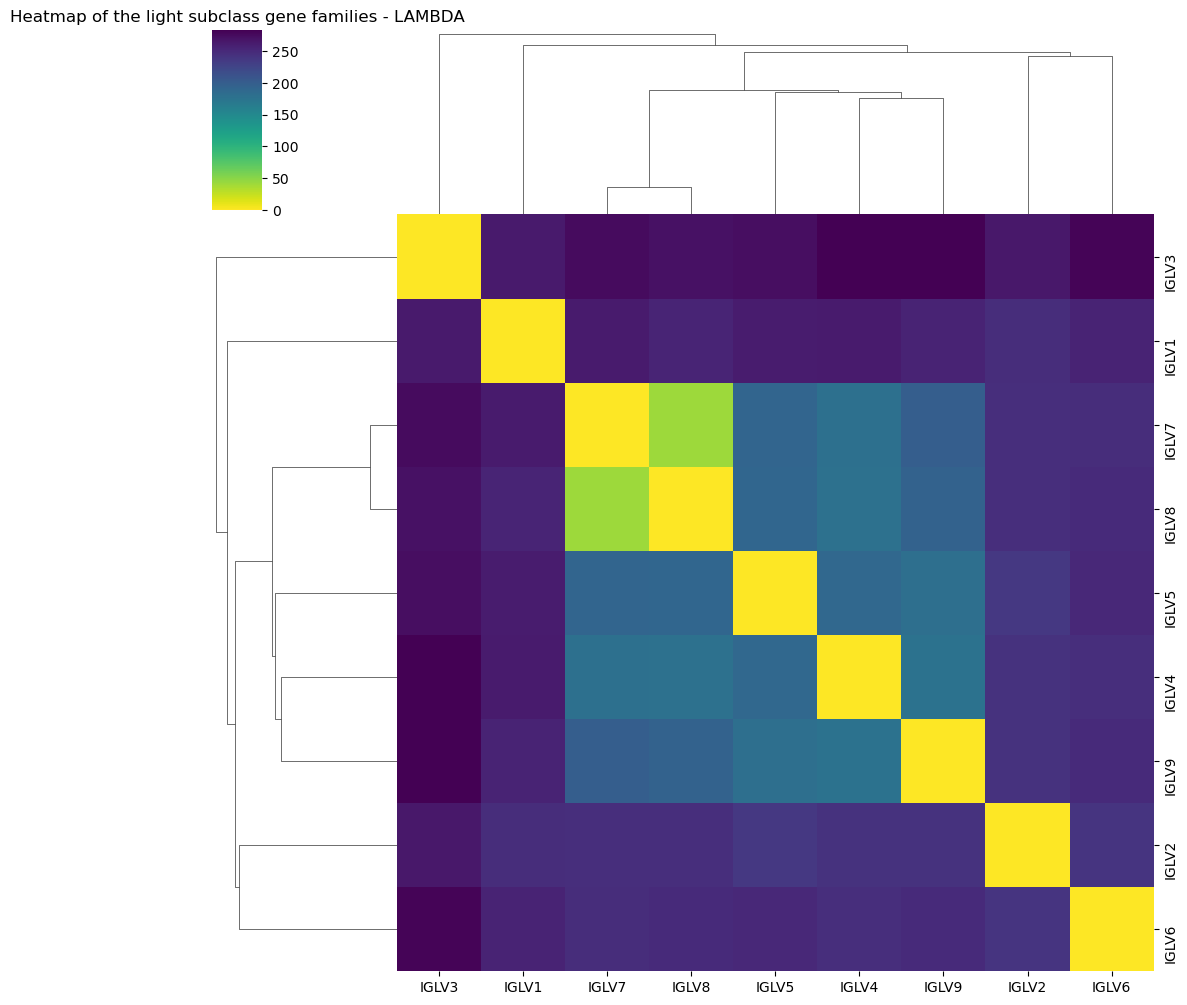

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

#split the kappa and lambda dictionaries 
kappa_consensus = {k: v for k, v in consensus_dict.items() if 'k' in k.lower()}
lambda_consensus = {k: v for k, v in consensus_dict.items() if 'l' in k.lower()}

max_len = max(len(seq) for seq in consensus_dict.values())

#padding the consensus sequences to the same lenght by adding '_' as an extention 
def pad(seq, length):
    return seq + "_" * (length - len(seq))

#saving padded consensus sequences
kappa_consensus_padded = {k: pad(v, max_len) for k, v in kappa_consensus.items()}
lambda_consensus_padded = {k: pad(v, max_len) for k, v in lambda_consensus.items()}

#defining function to cluster and plot both lambda and kappa sequences separately 
def cluster_and_plot(consensus_dict, title_prefix= ""):
   
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
    plt.title(f"Dedogram of light gene subclass based on consensus sequences - {title_prefix}")
    plt.ylabel("Distance", fontsize=10)
    plt.xlabel(f"{title_prefix} light subclass", fontsize=10)
    plt.tight_layout()
    plt.show()

    sns.clustermap(dist_matrix, row_linkage=linkage_matrix, col_linkage=linkage_matrix,
                   xticklabels=labels, yticklabels=labels, cmap="viridis_r")
    plt.title(f"Heatmap of the light subclass gene families - {title_prefix}")
    plt.show()

cluster_and_plot(kappa_consensus_padded, title_prefix="KAPPA")
cluster_and_plot(lambda_consensus_padded, title_prefix="LAMBDA")


In [20]:
#now to look if the clustered gene families correlate with the antigens the target 
gene_to_antigen_type = df_sars_hum.groupby('light_subclass')['antigen_species'].apply(set).to_dict()

#classifiying subclasses by antigen that they target
def classify_antigen_type(antigen_set):
    antigen_set = {s.lower().strip() for s in antigen_set}
    sars = [s for s in antigen_set if "coronavirus" in s]
    human = [s for s in antigen_set if "homo sapiens" in s]

    if sars and not human:
        return "SARS-CoV-2"
    elif human and not sars:
        return "homo sapiens"
    elif sars and human:
        return "both"

cleaned_antigen_map = {
    subclass: classify_antigen_type(antigens)
    for subclass, antigens in gene_to_antigen_type.items()
}

for subclass, label in cleaned_antigen_map.items():
    print(f"{subclass}: {label}")

with open("cleaned_antigen_map", "w") as f:
    json.dump(cleaned_antigen_map, f)

IGKV1: both
IGKV10: homo sapiens
IGKV12: homo sapiens
IGKV13: homo sapiens
IGKV14: homo sapiens
IGKV16: homo sapiens
IGKV19: homo sapiens
IGKV1D: homo sapiens
IGKV2: both
IGKV2D: homo sapiens
IGKV3: both
IGKV3D: homo sapiens
IGKV4: both
IGKV5: both
IGKV6: both
IGKV8: both
IGKV9: homo sapiens
IGLV1: both
IGLV2: both
IGLV3: both
IGLV4: SARS-CoV-2
IGLV5: both
IGLV6: both
IGLV7: both
IGLV8: both
IGLV9: SARS-CoV-2


In [14]:
#chi-square test on the table 
import pandas as pd
from scipy.stats import chi2_contingency

targeted_species = pd.read_csv("./targeted_species.csv")

#creating contingency table
contingency_table = pd.crosstab(targeted_species['light_subclass'], targeted_species['antigen_species'])

print(contingency_table)

#chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p}")


antigen_species  SARS-CoV-2  SARS-CoV-2 and homo sapiens  homo sapiens
light_subclass                                                        
IGKV1                     0                            1             0
IGKV10                    0                            0             1
IGKV12                    0                            0             1
IGKV13                    0                            0             1
IGKV14                    0                            0             1
IGKV16                    0                            0             1
IGKV19                    0                            0             1
IGKV1D                    0                            0             1
IGKV2                     0                            1             0
IGKV2D                    0                            0             1
IGKV3                     0                            1             0
IGKV3D                    0                            0             1
IGKV4 

In [15]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from skbio.stats.distance import mantel
import matplotlib.pyplot as plt
import seaborn as sns

#binary matrix for antigen targets to plot it as a dendigram

subclasses = sorted(cleaned_antigen_map.keys())
antigen_types = ['SARS-CoV-2', 'homo sapiens']  

binary_matrix = pd.DataFrame(0, index=subclasses, columns=antigen_types)

#both is split into 1 and 1
for subclass, target in cleaned_antigen_map.items():
    if target == 'both':
        binary_matrix.loc[subclass, :] = 1
    elif target in antigen_types:
        binary_matrix.loc[subclass, target] = 1

print("\nBinary antigen targeting matrix:\n", binary_matrix)


Binary antigen targeting matrix:
         SARS-CoV-2  homo sapiens
IGKV1            1             1
IGKV10           0             1
IGKV12           0             1
IGKV13           0             1
IGKV14           0             1
IGKV16           0             1
IGKV19           0             1
IGKV1D           0             1
IGKV2            1             1
IGKV2D           0             1
IGKV3            1             1
IGKV3D           0             1
IGKV4            1             1
IGKV5            1             1
IGKV6            1             1
IGKV8            1             1
IGKV9            0             1
IGLV1            1             1
IGLV2            1             1
IGLV3            1             1
IGLV4            1             0
IGLV5            1             1
IGLV6            1             1
IGLV7            1             1
IGLV8            1             1
IGLV9            1             0


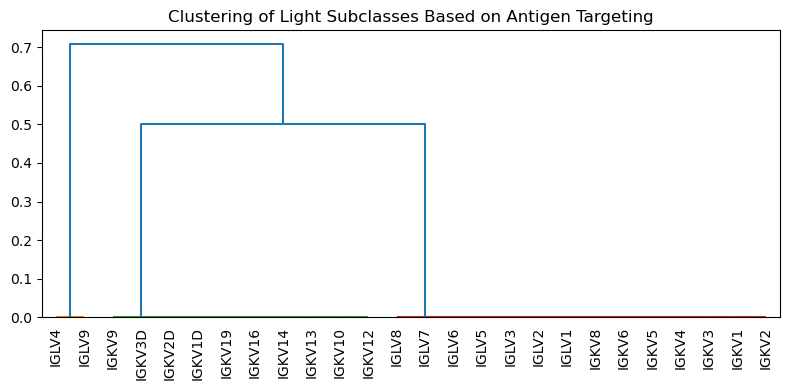

In [16]:
#dendogram of the binary matrix
dist_antigen = pdist(binary_matrix.values, metric='hamming')
linkage_antigen = linkage(dist_antigen, method='average')

plt.figure(figsize=(8, 4))
dendrogram(linkage_antigen, labels=binary_matrix.index, leaf_rotation=90)
plt.title("Clustering of Light Subclasses Based on Antigen Targeting")
plt.tight_layout()
plt.show()


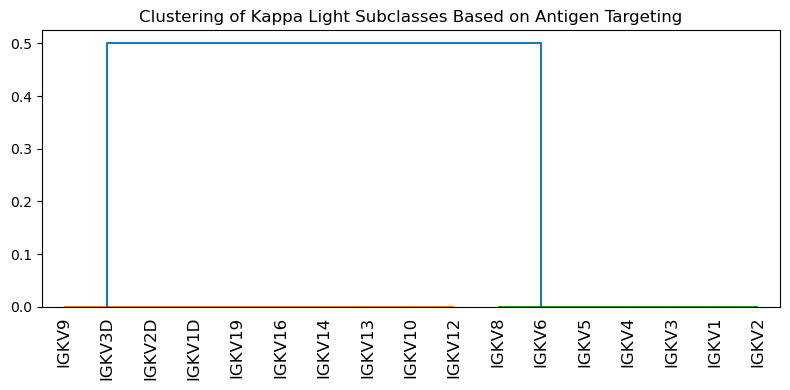

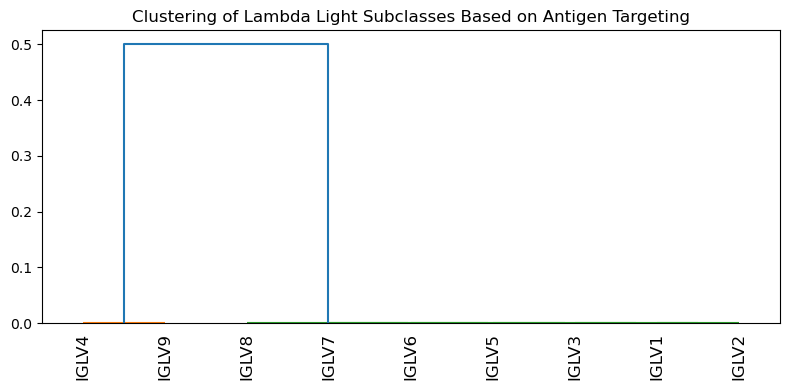

In [17]:
# Split into kappa and lambda based on the index (subclass names)
kappa_matrix = binary_matrix[binary_matrix.index.str.startswith("IGKV")]
lambda_matrix = binary_matrix[binary_matrix.index.str.startswith("IGLV")]

dist_kappa = pdist(kappa_matrix.values, metric='hamming')
linkage_kappa = linkage(dist_kappa, method='average')
plt.figure(figsize=(8, 4))
dendrogram(linkage_kappa, labels=kappa_matrix.index, leaf_rotation=90)
plt.title("Clustering of Kappa Light Subclasses Based on Antigen Targeting")
plt.tight_layout()
plt.show()

dist_lambda = pdist(lambda_matrix.values, metric='hamming')
linkage_lambda = linkage(dist_lambda, method='average')
plt.figure(figsize=(8, 4))
dendrogram(linkage_lambda, labels=lambda_matrix.index, leaf_rotation=90)
plt.title("Clustering of Lambda Light Subclasses Based on Antigen Targeting")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import mantel
from collections import defaultdict
from itertools import combinations
import random

np.random.seed(42)
random.seed(42)

def jaccard_distance(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return 1 - intersection / union if union > 0 else 1.0

#
kappa_antigen_map = {k: v for k, v in cleaned_antigen_map.items() if k in kappa_consensus_padded}
lambda_antigen_map = {k: v for k, v in cleaned_antigen_map.items() if k in lambda_consensus_padded}


def run_mantel_and_plot(consensus_dict, antigen_map, label=""):
    #
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())
    
    #
    dist_consensus = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    dm1 = DistanceMatrix(squareform(dist_consensus), ids=labels)
    
    #
    antigen_sets = [set(map(str.lower, antigen_map.get(l, set()))) for l in labels]
    
    #
    dist_antigen = np.zeros((len(labels), len(labels)))
    for i, j in combinations(range(len(labels)), 2):
        d = jaccard_distance(antigen_sets[i], antigen_sets[j])
        dist_antigen[i, j] = dist_antigen[j, i] = d
    dm2 = DistanceMatrix(dist_antigen, ids=labels)

    #
    common = list(set(dm1.ids) & set(dm2.ids))
    dm1_filtered = dm1.filter(common)
    dm2_filtered = dm2.filter(common)

    #
    r_val, p_val, _ = mantel(dm1_filtered, dm2_filtered, method='spearman', permutations=999)

    print(f"\nMantel Test Result ({label}):")
    print(f"Spearman correlation between distance matrices: r = {r_val:.4f}")
    print(f"P-value: {p_val:.4f}")

run_mantel_and_plot(kappa_consensus_padded, kappa_antigen_map, label="Kappa light chains")
run_mantel_and_plot(lambda_consensus_padded, lambda_antigen_map, label="Lambda light chains")



Mantel Test Result (Kappa light chains):
Spearman correlation between distance matrices: r = 0.3557
P-value: 0.0010

Mantel Test Result (Lambda light chains):
Spearman correlation between distance matrices: r = -0.1948
P-value: 0.5510


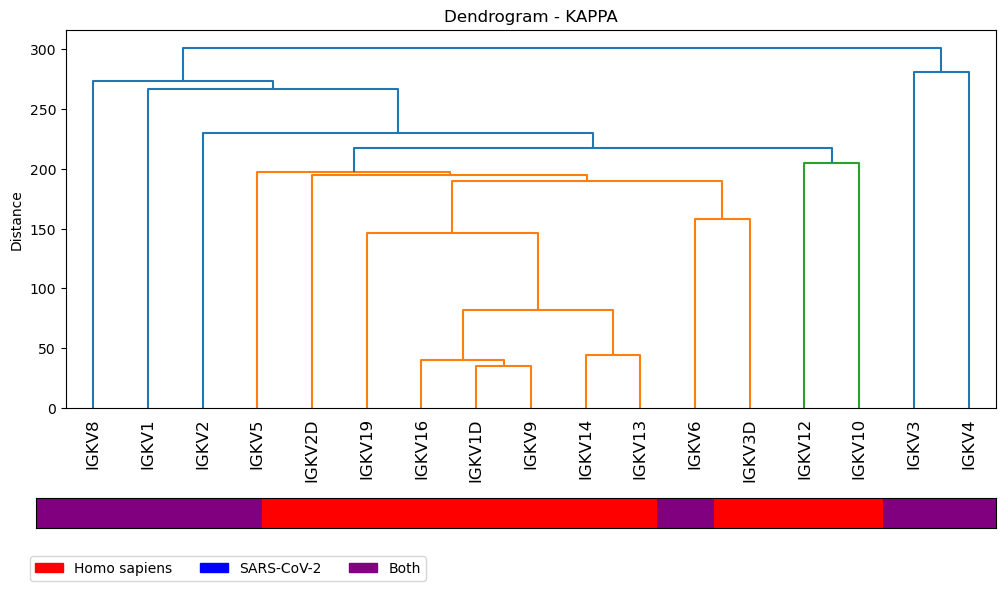

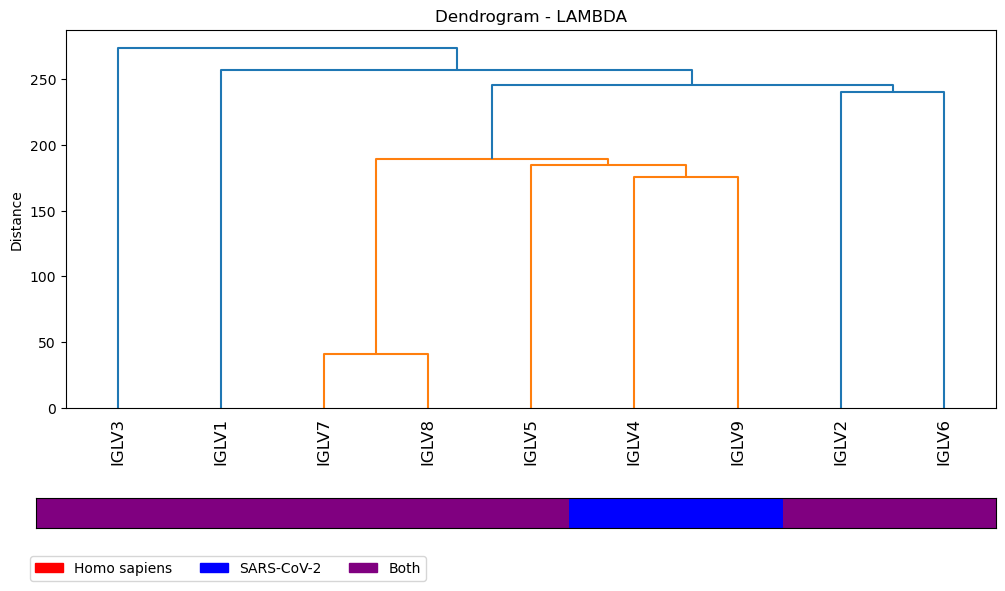

In [23]:
# now i would like to plot the dendrogram based on consensus sequences and annotate it with the antigen species that it targets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.patches as mpatches
def pad(seq, length):
    return seq + "_" * (length - len(seq))

def cluster_and_plot(consensus_dict, cleaned_antigen_map, color_map, title_prefix=""):
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.subplots_adjust(bottom=0.25)

    dendro = dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title(f"Dendrogram - {title_prefix}")
    ax.set_ylabel("Distance")

    # Get order of labels from dendrogram
    label_order = dendro["ivl"]
    species_list = [cleaned_antigen_map.get(label, "") for label in label_order]
    color_names = [color_map.get(species, "gray") for species in species_list]
    rgb_colors = [to_rgb(c) for c in color_names]

    # Add color strip as image (RGB values)
    color_ax = fig.add_axes([0.1, 0.05, 0.8, 0.05])
    color_ax.imshow([rgb_colors], aspect="auto")
    color_ax.set_xticks([])
    color_ax.set_yticks([])
 
    legend_patches = [
        mpatches.Patch(color=color_map["homo sapiens"], label="Homo sapiens"),
        mpatches.Patch(color=color_map["SARS-CoV-2"], label="SARS-CoV-2"),
        mpatches.Patch(color=color_map["both"], label="Both")
    ]
    plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.2, -2), ncol=3)

    plt.show()


# Plot
cluster_and_plot(kappa_consensus_padded, cleaned_antigen_map, color_map, title_prefix="KAPPA")
cluster_and_plot(lambda_consensus_padded, cleaned_antigen_map, color_map, title_prefix="LAMBDA")
